In [2]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO01_hand_puncher_1 cam0
INFO     | _get_names | Track & Cam : MOO01_hand_puncher_1 cam1
INFO     | _get_names | Track & Cam : MOO02_hand_puncher_2 cam0
INFO     | _get_names | Track & Cam : MOO02_hand_puncher_2 cam1
INFO     | _get_names | Track & Cam : MOO03_hand_shooter_easy cam0
INFO     | _get_names | Track & Cam : MOO03_hand_shooter_easy cam1
INFO     | _get_names | Track & Cam : MOO04_hand_shooter_hard cam0
INFO     | _get_names | Track & Cam : MOO04_hand_shooter_hard cam1
INFO     | _get_names | Track & Cam : MOO06_inspect_hard cam0
INFO     | _get_names | Track & Cam : MOO06_inspect_hard cam1
INFO     | _get_names | Track & Cam : MOO08_mapping_hard cam0
INFO     | _get_names | Track & Cam : MOO08_mapping_hard cam1
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam0
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam1
INFO     | s

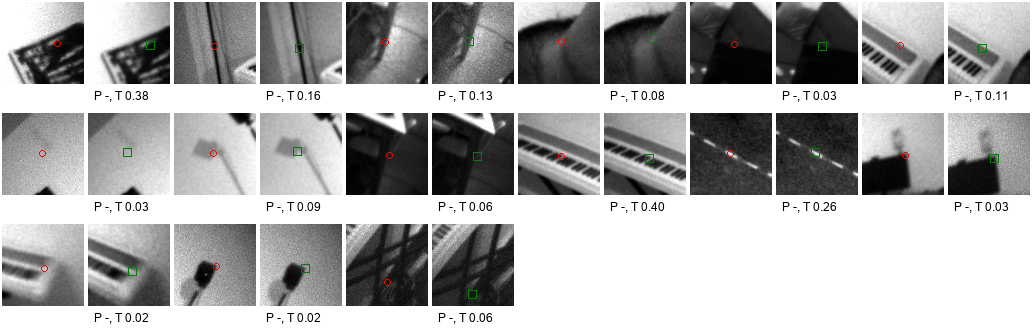

In [11]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences, cert, est_keypoints = batch

# print(f'{ref_keypoints[:6]=}')
# print(f'{tar_keypoints[:6]=}')

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    ref_keypoints, tar_keypoints,
    tar_keypoints,

    confidences_true=confidences,
    
    limit_count=count, 

    n_columns=6,
    just_gt=True,
)

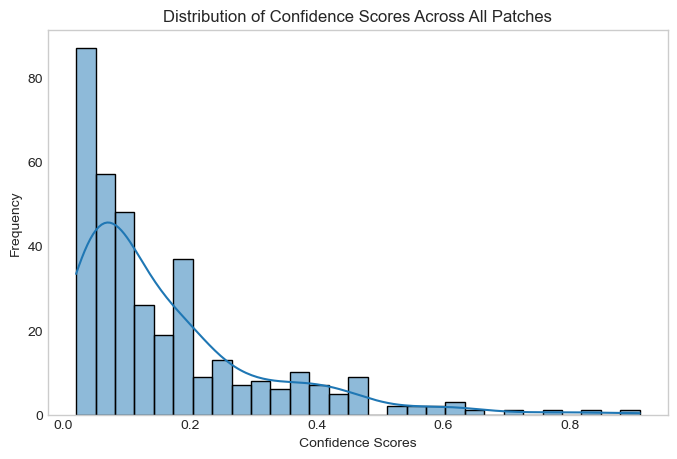

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confidence_distribution(dataloader, N=None):
    all_confidences = []
    
    for i, batch in enumerate(dataloader):
        if N is not None and i >= N:
            break
        _, _, _, _, confidences, _, _ = batch
        all_confidences.extend(confidences.cpu().numpy())
    
    all_confidences = np.array(all_confidences)
    
    # Adjust for skewed distribution by equalizing bins
    min_conf, max_conf = all_confidences.min(), all_confidences.max()
    bins = np.linspace(min_conf, max_conf, 30)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(all_confidences, bins=bins, kde=True)
    plt.xlabel("Confidence Scores")
    plt.ylabel("Frequency")
    plt.title("Distribution of Confidence Scores Across All Patches")
    plt.grid()
    plt.show()


dl = dm.train_dataloader()
plot_confidence_distribution(dl)

# Light

In [ ]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

12,767,369


In [9]:
target_coords, target_confidences = light(
    ref_patches, 
    tar_patches, 
    ref_keypoints
)

# target_confidences = F.sigmoid(target_confidences)

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

target_coords.shape=torch.Size([15, 2])
target_confidences.shape=torch.Size([15, 1])


In [11]:
coords = np.array([0, 0])
coords * ((82 - 1) / 2) + (82 - 1) / 2

KeyboardInterrupt: 

In [11]:
coords = np.array([0, 0])
(coords - (82 - 1) / 2) / ((82 - 1) / 2)

array([-1., -1.])